In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()

matplotlib.rcParams['font.family'] = "Arial"
matplotlib.rcParams['font.sans-serif'] = ["Arial"]


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8

['/content/drive/MyDrive/NU work/Font/Arial.ttf', '/content/drive/MyDrive/NU work/Font/Arial Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold Italic.ttf']


In [ ]:
lca_result = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/lca results for plot.xlsx',
                           sheet_name='Sheet2', skiprows=33, usecols=range(0,9), index_col=0)
print(lca_result)


        Herbicides  Insecticides  Phosphoric acid P2O5  Potassium Oxide  \
GHG100         NaN           NaN                   NaN              NaN   
2024        9.5542       14.6083               54.5213          12.9050   
2029        8.0942       13.4678               51.5148          12.8676   
2039        7.3086       12.8385               49.7979          12.7613   
2049        7.0861       12.6617               49.3348          12.7539   
Energy         NaN           NaN                   NaN              NaN   
2024      154.0334      214.7746              809.6324         295.7762   
2029      143.2521      206.4975              787.4021         295.2766   
2039      137.0021      201.4589              773.3085         294.0062   
2049      135.4298      200.2099              770.0356         293.9543   
GHG100         NaN           NaN                   NaN              NaN   
2024        9.5542       14.6083               54.5213          12.9050   
2029        8.0942       

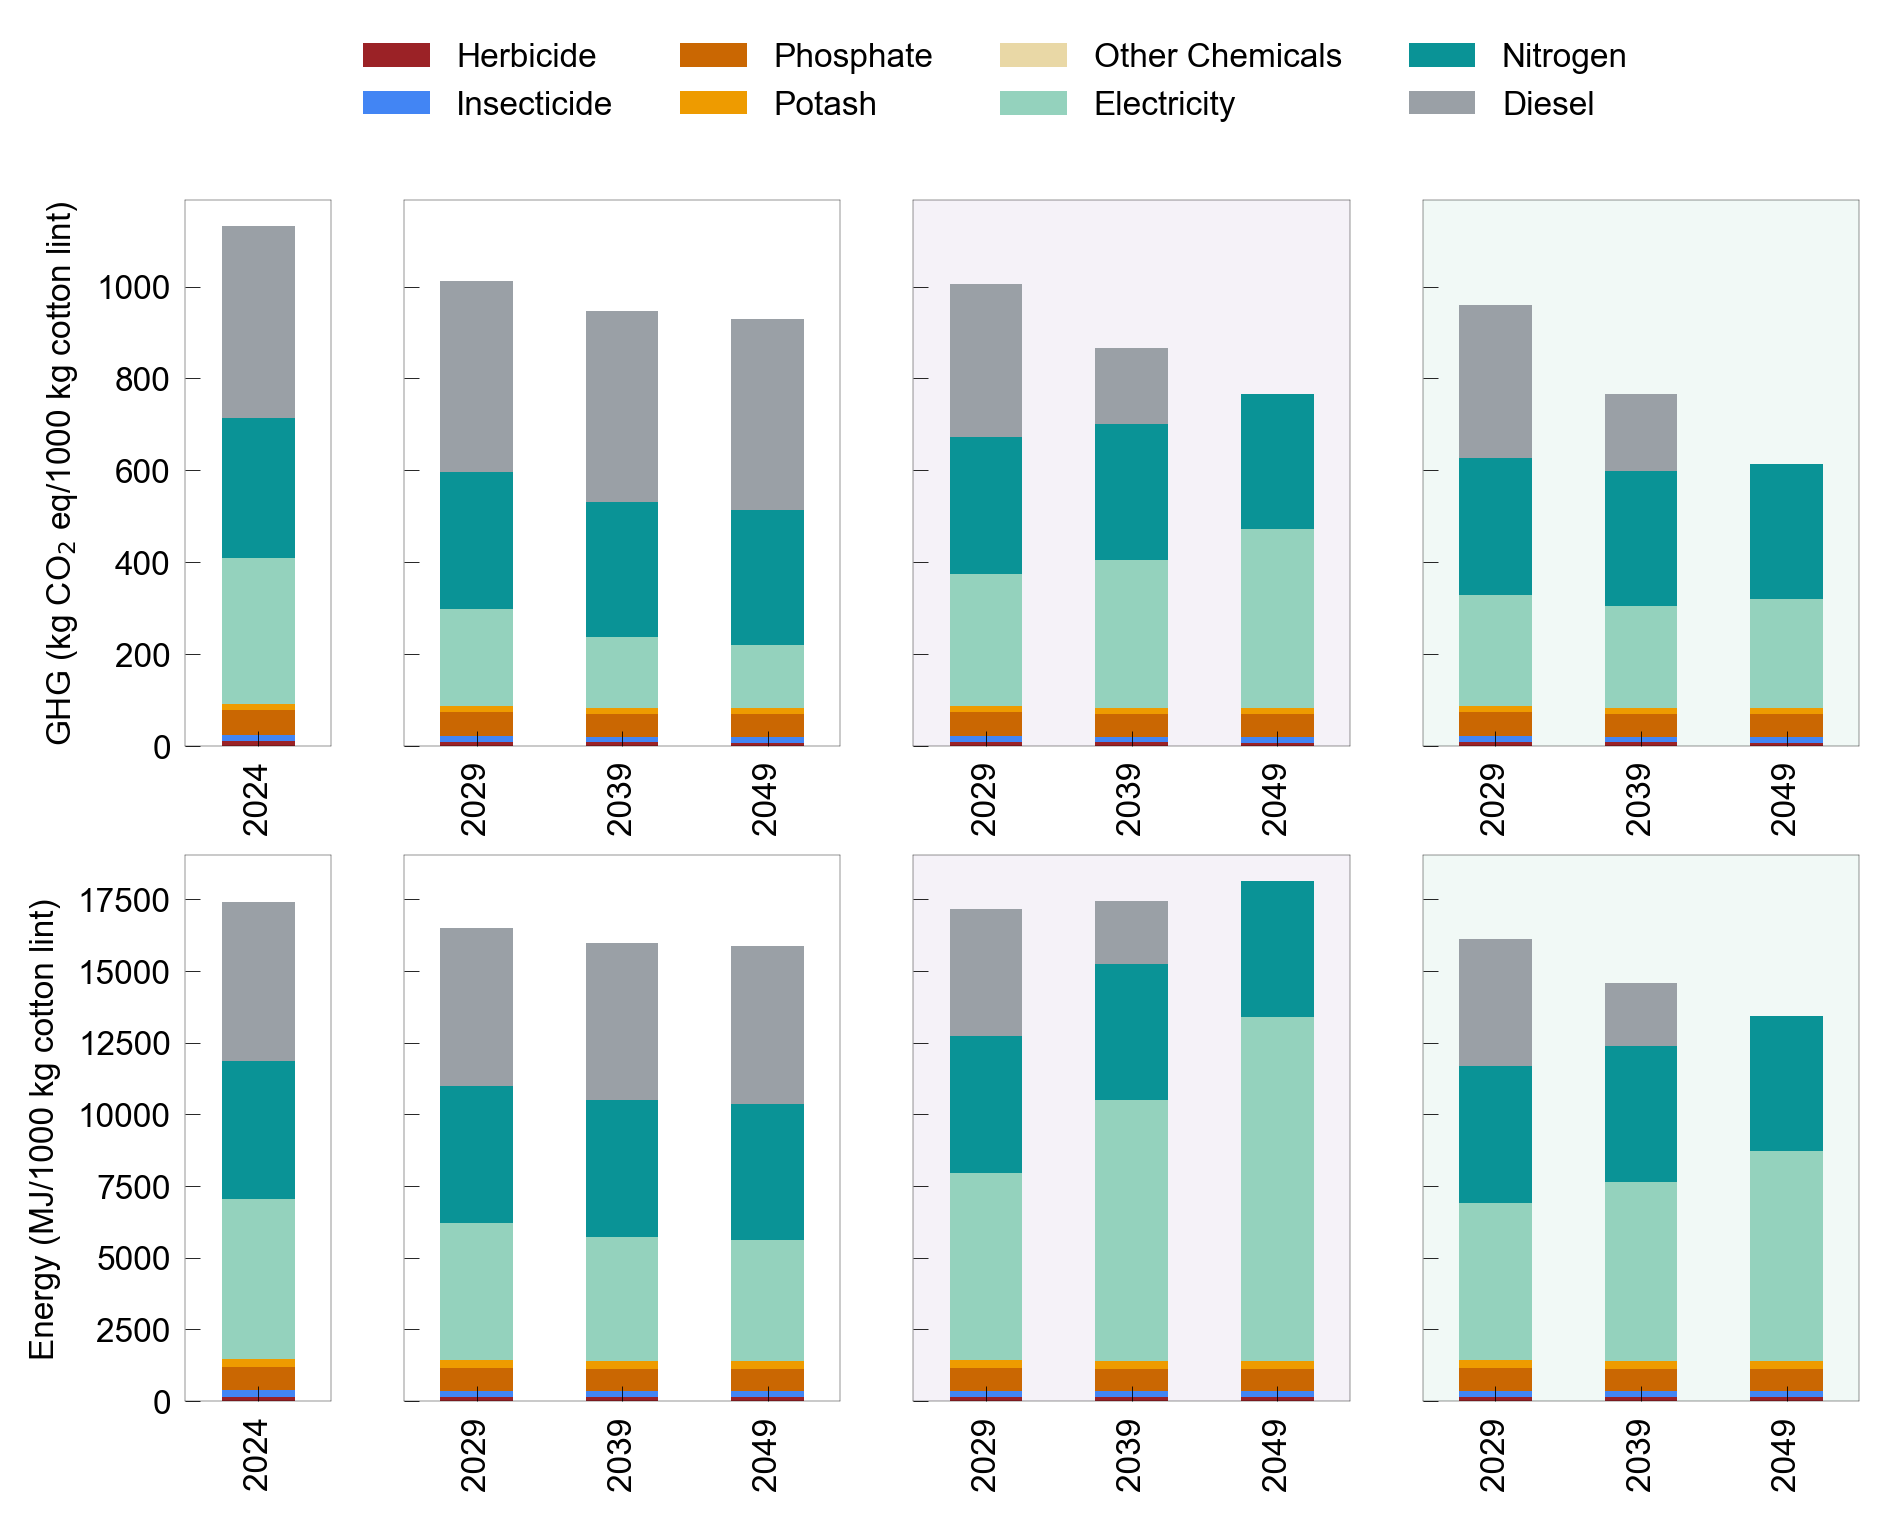

In [ ]:
# Plotting stacked bar chart

df_GHG_base = lca_result.iloc[1:2]
df_GHG_1 = lca_result.iloc[2:5]
df_GHG_2 = lca_result.iloc[12:15]
df_GHG_3 = lca_result.iloc[22:25]


df_energy_base = lca_result.iloc[6:7]
df_energy_1 = lca_result.iloc[7:10]
df_energy_2 = lca_result.iloc[17:20]
df_energy_3 = lca_result.iloc[27:30]


colors = list(reversed(['#9AA0A6', '#0A9396', '#94D2BD', '#E9D8A6',
          '#EE9B00', '#CA6702', '#4285F4', '#9b2226']))



width_ratios = [1, 3, 3, 3]
# Create the figure and axes with the specified width ratios
fig, axs = plt.subplots(2, 4, figsize=(7.2, 5.2), gridspec_kw={'width_ratios': width_ratios})

for i in range(4):  # First row
    axs[0, i].sharey(axs[0, 0])

for i in range(4):  # Second row
    axs[1, i].sharey(axs[1, 0])

for ax in axs.flat:
    ax.tick_params(axis='both', width=0.2)
    for spine in ax.spines.values():
      spine.set_linewidth(0.1)

df_GHG_base.plot(ax=axs[0,0], kind='bar', stacked=True, color=colors,legend=False)
df_GHG_1.plot(ax=axs[0,1], kind='bar', stacked=True,  color=colors,legend=False)

axs[0,2].set_facecolor("#F5F2F8")
df_GHG_2.plot(ax=axs[0,2], kind='bar', stacked=True,  color=colors,legend=False)
axs[0,3].set_facecolor("#F1F9F6")
df_GHG_3.plot(ax=axs[0,3], kind='bar', stacked=True, color=colors,legend=False)


df_energy_base.plot(ax=axs[1,0], kind='bar', stacked=True, color=colors,legend=False)
df_energy_1.plot(ax=axs[1,1], kind='bar', stacked=True,  color=colors,legend=False)
axs[1,2].set_facecolor("#F5F2F8")
df_energy_2.plot(ax=axs[1,2], kind='bar', stacked=True,  color=colors,legend=False)
axs[1,3].set_facecolor("#F1F9F6")
df_energy_3.plot(ax=axs[1,3], kind='bar', stacked=True, color=colors,legend=False)

# Labels & Title
# plt.xlabel("Index")
axs[0, 0].set_ylabel(r"GHG (kg CO$_2$ eq/1000 kg cotton lint)")
axs[1,0].set_ylabel("Energy (MJ/1000 kg cotton lint)")
# plt.title("Stacked Bar Chart of Chemicals Used")
# Create one legend from the first subplot
handles, labels = axs[0, 0].get_legend_handles_labels()

custom_labels = ['Herbicide', 'Insecticide', 'Phosphate', 'Potash', 'Other Chemicals', 'Electricity', 'Nitrogen', 'Diesel']

fig.legend(handles, custom_labels, loc='upper center', bbox_to_anchor=(0.5, 1), frameon=False, ncol=4)
# fig.subplots_adjust(top=0.85)
# Show plot
# plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/lca results.tiff')
plt.show()

               0            1            2            3            4  \
0    1465.208478  1270.159329  1479.309369  1739.696783  1419.005289   
1    1222.362178  1088.707856  1195.120253  1553.681320  1225.120750   
2    1703.197772  1473.724889  1627.582798  1934.878723  1727.783509   
3    1305.837937  1113.754690  1325.170739  1584.691422  1291.160464   
4    1186.263324  1050.919881  1233.329333  1490.571822  1153.573702   
..           ...          ...          ...          ...          ...   
995  1402.752604  1187.838848  1439.858917  1652.623827  1304.396247   
996  1468.665554  1263.768724  1424.699094  1741.600225  1419.392318   
997  1159.407753  1017.845673  1186.955187  1488.488114  1147.879332   
998  1230.873326  1105.975744  1216.251819  1558.766000  1280.076924   
999  1390.682268  1206.517459  1400.619111  1668.534836  1416.781432   

               5            6            7            8            9  ...  \
0    1291.829263  1273.263906  1267.517055  1444.601554  1

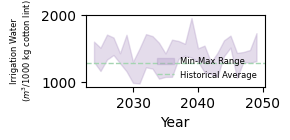

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Sample data
irrigation_data = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/predicted_raw_water_consumption.xlsx',usecols=lambda column: column not in ['Unnamed: 0'])
# print(irrigation_data)

sampling_water_percent = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/processed_data and results/sampling_for_production_percentage.xlsx', usecols=lambda column: column not in ['Unnamed: 0'])

# print(sampling_water_percent)

ua_data = sampling_water_percent.dot(irrigation_data)
print(ua_data)

fig, ax = plt.subplots(1, 1, figsize=(3, 1.5))

# Extract the mean values for each range of columns
line1 = np.array(ua_data.mean(axis=0)[0:26])
line2 = np.array(ua_data.mean(axis=0)[26:52])
line3 = np.array(ua_data.mean(axis=0)[52:78])
line4 = np.array(ua_data.mean(axis=0)[78:104])

# Calculate the maximum and minimum values across the four lines
max_values = np.maximum.reduce([line1, line2, line3, line4])
min_values = np.minimum.reduce([line1, line2, line3, line4])

# Define the x-values
x_values = np.arange(2024, 2050)


colors = ['#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']


# Plot each line
# plt.plot(x_values, line1, label='SSP1-2.6', color='#9AA0A6', ls='--', lw=1)
# plt.plot(x_values, line2, label='SSP2-4.5', color='#EA4335', ls='--', lw=1)
# plt.plot(x_values, line3, label='SSP3-7.0', color='#FBBC04', ls='--', lw=1)
# plt.plot(x_values, line4, label='SSP5-8.5', color='#4285F4', ls='--', lw=1)

# Fill between the min and max values
plt.fill_between(x_values, min_values, max_values, color='#A88EC0', alpha=0.3, label='Min-Max Range')
plt.axhline(y=1278.4, color='#A4D5B1', linestyle='--', linewidth=1, label='Historical Average')

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Irrigation Water\n($m^3$/1000 kg cotton lint)', fontsize=6)
# plt.title('Plot with Filled Area Between Min and Max')
plt.legend(frameon=False, loc='lower right', fontsize=6)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_maxmin.tiff',dpi=300, bbox_inches='tight')
# Show the plot
plt.show()